In [1]:
import json
# from torch.utils.data.distributed import DistributedSampler
from core.dataset import *
from core.prefetch_dataloader import PrefetchDataLoader, CPUPrefetcher
from core.utils import get_blurred_masked_frames
import torch
import os
import numpy as np
import matplotlib.pyplot as plt

# propogation
from model.propainter import BidirectionalPropagation, InpaintGenerator
from model.recurrent_flow_completion import RecurrentFlowCompleteNet


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

config = json.load(open("./configs/train_depthpainter.json"))
config["world_size"] = torch.cuda.device_count()
# config["init_method"] = f"tcp://{get_master_ip()}:{args.port}"
config["distributed"] = False

if "local_rank" not in config:
    config["local_rank"] = config["global_rank"] = torch.cuda.device_count()
if torch.cuda.is_available():
    config["device"] = torch.device("cuda:{}".format(config["local_rank"]))
    print("Using ", torch.cuda.get_device_name(0))
else:
    config["device"] = "cpu"
    print("No GPU found, using CPU instead")


youtube_vos_train = TrainDataset(config["dl_config"], config["youtube-vos"])
bvidvc_train = TrainDataset(config["dl_config"], config["bvidvc"])
low_light_10_train = TrainDataset(config["dl_config"], config["low_light_10"])

datasets_train = [youtube_vos_train]

train_sampler = Sampler(datasets_train, iter=True)
train_args = config["trainer"]


dataloader_args = dict(
    dataset=train_sampler,
    batch_size=train_args["batch_size"] // config["world_size"],
    shuffle=True,
    num_workers=train_args["num_workers"],
    drop_last=True,
)

train_loader = PrefetchDataLoader(
    train_args["num_prefetch_queue"], **dataloader_args
)
prefetcher = CPUPrefetcher(train_loader)


netG = InpaintGenerator();
netG.to("cuda:0");


fix_flow_complete = RecurrentFlowCompleteNet(
    "./weights/recurrent_flow_completion.pth"
)
for p in fix_flow_complete.parameters():
    p.requires_grad = False
fix_flow_complete.to("cuda:0")
fix_flow_complete.eval();

Using  NVIDIA GeForce RTX 4090
Network [InpaintGenerator] was created. Total number of parameters: 39.4 million. To see the architecture, do print(network).
Pretrained flow completion model has loaded.


In [ ]:
data = next(iter(train_loader))
frames, masks, depths, flows_f, flows_b, video_name = data
frames = (frames + 1) / 2.0

# masked_frames = get_blurred_masked_frames(frames, masks)
masked_frames = frames * (1 - masks)

# img = 0


# fig, axs = plt.subplots(10, 4, figsize=(8, 18))

# for i in range(0,10):
    
#     axs[i, 0].imshow(frames[img][i].permute(1, 2, 0).numpy())
#     axs[i, 0].axis('off')
#     axs[i, 0].set_title(f'Frame {i+1}')

#     axs[i, 1].imshow(depths[img][i].squeeze().numpy(), cmap='gray')
#     axs[i, 1].axis('off')
#     axs[i, 1].set_title(f'Depth {i+1}')

#     axs[i, 2].imshow(masks[img][i].squeeze().numpy(), cmap='gray')
#     axs[i, 2].axis('off')
#     axs[i, 2].set_title(f'Mask {i+1}')

#     axs[i, 3].imshow(masked_frames[img][i].cpu().numpy().transpose(1, 2, 0))
#     axs[i, 3].axis('off')
#     axs[i, 3].set_title(f'Blurred Frame {i+1}')

# plt.tight_layout()
# plt.show()


In [ ]:
# frames = (frames + 1) / 2.0
frames = frames * 2.0 - 1

flow viz

In [ ]:
# from torchvision.utils import flow_to_image
# import matplotlib.pyplot as plt

# flow_img_f = flow_to_image(flows_f[0][0].cpu().float())
# flow_img_b = flow_to_image(flows_b[0][0].cpu().float())

# fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# axs[0].imshow(flow_img_f.permute(1, 2, 0).numpy())
# axs[0].set_title('Forward Flow')
# axs[0].axis('off')

# axs[1].imshow(flow_img_b.permute(1, 2, 0).numpy())
# axs[1].set_title('Backward Flow')
# axs[1].axis('off')

# plt.tight_layout()
# plt.show()



Propogation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


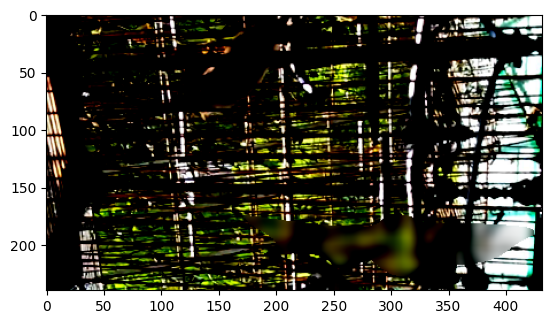

In [ ]:
device = "cuda:0"
l_t = 10


frames, depths, masks = (
    frames.to(device),
    depths.to(device).float(),
    masks.to(device).float(),
)
masked_frames = get_blurred_masked_frames(frames, masks)
# masked_frames = frames * (1 - masks)


masked_local_frames = masked_frames[:, :l_t, ...]
gt_local_frames = frames[:, :l_t, ...]
local_depths = depths[:, :l_t, ...]
b, t, c, h, w = frames.size()

plt.imshow(masked_frames[0][0].cpu().numpy().transpose(1, 2, 0))

In [ ]:
local_masks = masks[:, :l_t, ...].contiguous()
gt_flows_bi = (flows_f.to("cuda:0"), flows_b.to("cuda:0"))

pred_flows_bi, _ = fix_flow_complete.forward_bidirect_flow(
    gt_flows_bi, local_masks
)
pred_flows_bi = fix_flow_complete.combine_flow(
    gt_flows_bi, pred_flows_bi, local_masks
)

In [ ]:
img_prop_module = BidirectionalPropagation(3, learnable=False)

_, _, prop_imgs, updated_local_masks = img_prop_module(
    masked_local_frames,
    pred_flows_bi[0],
    pred_flows_bi[1],
    local_masks,
    interpolation="nearest"
)

In [ ]:
updated_masks = masks.clone()
updated_masks[:, :l_t, ...] = updated_local_masks.view(b, l_t, 1, h, w)

updated_frames = masked_frames.clone()
prop_local_frames = (
    gt_local_frames * (1 - local_masks)
    + prop_imgs.view(b, l_t, 3, h, w) * local_masks
)  # merge
updated_frames[:, :l_t, ...] = prop_local_frames

updated_frames = (updated_frames + 1) / 2.0

In [ ]:
# gt_local_frames = gt_local_frames * 2.0 - 1
# gt_local_frames = (gt_local_frames + 1) / 2.0

In [ ]:
# fsfd = gt_local_frames * (1 - local_masks) #+ prop_imgs.view(b, l_t, 3, h, w) * local_masks

# plt.imshow(fsfd[0][0].cpu().numpy().transpose(1, 2, 0))

In [2]:
import importlib, sys
importlib.reload(sys.modules['model.propainter'])
from model.propainter import InpaintGenerator

In [5]:
model = InpaintGenerator()
pp_checkpoint = 
# pp_checkpoint = torch.load("./weights/ProPainter.pth")
model.load_state_dict(torch.load("./weights/ProPainter.pth"))
model.to("cuda:0")
model.eval()

with torch.no_grad():
    pred_imgs = model(updated_frames, pred_flows_bi, masks, updated_masks, l_t)

Network [InpaintGenerator] was created. Total number of parameters: 39.4 million. To see the architecture, do print(network).


NameError: name 'updated_frames' is not defined

In [ ]:
pred_imgs = netG(updated_frames, depths, pred_flows_bi, masks, updated_masks, l_t)


In [ ]:
pred_local_frames = pred_imgs[:, :l_t, ...]
comp_local_frames = (
    gt_local_frames * (1.0 - local_masks) + pred_local_frames * local_masks
)
comp_imgs = frames * (1.0 - masks) + pred_imgs * masks

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


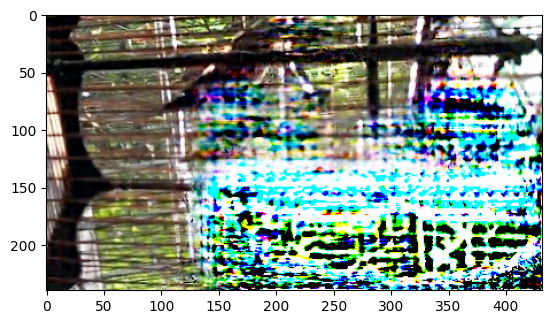

In [ ]:
plt.imshow(pred_local_frames[0][0].detach().cpu().numpy().transpose(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


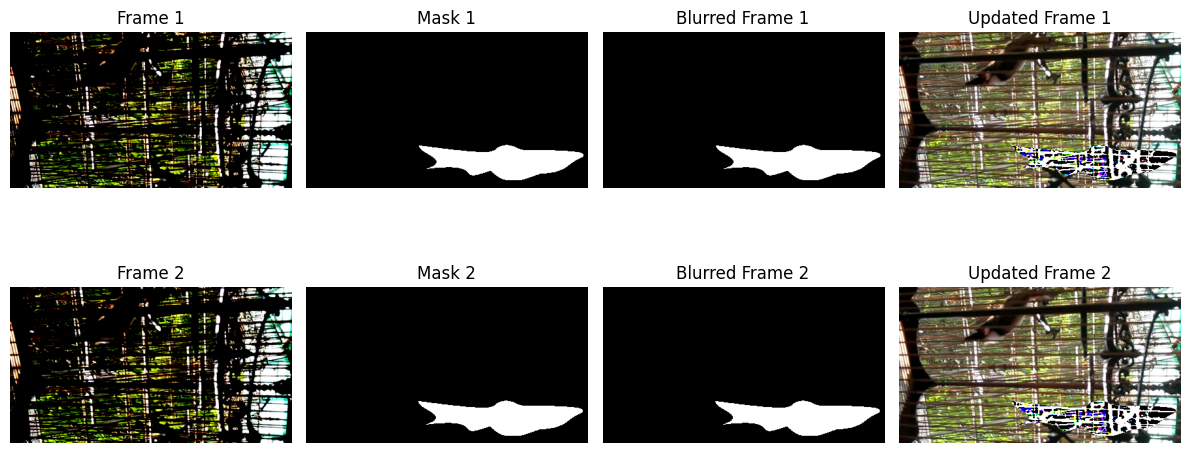

In [ ]:
img = 0


fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for i in range(0,2):
    
    axs[i, 0].imshow(frames[img][i].cpu().permute(1, 2, 0).numpy())
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'Frame {i+1}')

    axs[i, 1].imshow(masks[img][i].cpu().squeeze().numpy(), cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'Mask {i+1}')

    axs[i, 2].imshow(updated_masks[img][i].cpu().numpy().transpose(1, 2, 0), cmap='gray')
    axs[i, 2].axis('off')
    axs[i, 2].set_title(f'Blurred Frame {i+1}')

    axs[i, 3].imshow(updated_frames[img][i].cpu().numpy().transpose(1, 2, 0))
    axs[i, 3].axis('off')
    axs[i, 3].set_title(f'Updated Frame {i+1}')

plt.tight_layout()
plt.show()


In [ ]:
masked_frames = updated_frames
completed_depths = depths
completed_flows = pred_flows_bi
masks_in = masks
masks_updated = updated_masks
b, t, _, ori_h, ori_w = updated_frames.size()

cat = torch.cat(
    [
        masked_frames.view(b * t, 3, ori_h, ori_w),
        masks_in.view(b * t, 1, ori_h, ori_w),
        masks_updated.view(b * t, 1, ori_h, ori_w),
        completed_depths.view(b * t, 1, ori_h, ori_w),
    ],
    dim=1,
)

_, c, h, w = cat.size()

In [ ]:
import torch.nn.functional as F

ds_mask_in = F.interpolate(
masks_in.reshape(-1, 1, ori_h, ori_w), scale_factor=1 / 4, mode="nearest"
)
# .view(b, t, 1, h, w)

In [ ]:

# img = 0
# fig, axs = plt.subplots(len(pred_imgs[img]), 3, figsize=(8, 18))

# for i in range(0,len(pred_imgs[img])):
    
#     axs[i, 0].imshow(updated_frames[img][i].cpu().permute(1, 2, 0).numpy(), cmap = 'gray')
#     axs[i, 0].axis('off')
#     axs[i, 0].set_title(f'Input Frame {i+1}')

#     axs[i, 1].imshow(pred_imgs[img][i].cpu().permute(1, 2, 0).detach().numpy(), cmap='gray')
#     axs[i, 1].axis('off')
#     axs[i, 1].set_title(f'Pred Images {i+1}')

#     axs[i, 2].imshow(updated_masks[img][i].cpu().squeeze().numpy(), cmap='gray')
#     axs[i, 2].axis('off')
#     axs[i, 2].set_title(f'Updated Masks {i+1}')



# plt.tight_layout()
# plt.show()



# img = 3
# fig, axs = plt.subplots(10, 4, figsize=(8, 18))

# for i in range(0,10):
    
#     axs[i, 0].imshow(frame_tensors[img][i].permute(1, 2, 0).numpy())
#     axs[i, 0].axis('off')
#     axs[i, 0].set_title(f'Frame {i+1}')

#     axs[i, 1].imshow(prop_frames[img][i].cpu().permute(1, 2, 0).numpy(), cmap='gray')
#     axs[i, 1].axis('off')
#     axs[i, 1].set_title(f'Prop Frame {i+1}')

#     axs[i, 2].imshow(masks[img][i].cpu().squeeze().numpy(), cmap='gray')
#     axs[i, 2].axis('off')
#     axs[i, 2].set_title(f'Mask {i+1}')

#     axs[i, 3].imshow(updated_masks[img][i].cpu().squeeze().numpy(), cmap='gray')
#     axs[i, 3].axis('off')
#     axs[i, 3].set_title(f'Updated Mask {i+1}')


# plt.tight_layout()
# plt.show()

In [ ]:
x = masked_local_frames
flows_forward =  pred_flows_bi[0]
flows_backward=pred_flows_bi[1]
mask = local_masks
interpolation="nearest"

from model.propainter import fbConsistencyCheck
from model.modules.flow_loss_utils import flow_warp
import torch.nn as nn

deform_align = nn.ModuleDict()
learnable = False


"""
x shape : [b, t, c, h, w]
return [b, t, c, h, w]
"""

def binary_mask(mask, th=0.1):
    mask[mask > th] = 1
    mask[mask <= th] = 0
    # return mask.float()
    return mask.to(mask)

# For backward warping
# pred_flows_forward for backward feature propagation
# pred_flows_backward for forward feature propagation
b, t, c, h, w = x.shape
feats, masks = {}, {}
feats["input"] = [x[:, i, :, :, :] for i in range(0, t)]
masks["input"] = [mask[:, i, :, :, :] for i in range(0, t)]

prop_list = ["backward_1", "forward_1"]
cache_list = ["input"] + prop_list

frame_idx = range(0, t)
frame_idx = frame_idx[::-1]

In [ ]:
import random
length = 150
sample_length = 20
num_ref_frame = 15

complete_idx_set = list(range(length))
pivot = random.randint(0, length - sample_length)
local_idx = complete_idx_set[pivot : pivot + sample_length]
remain_idx = list(set(complete_idx_set) - set(local_idx))
ref_index = sorted(random.sample(remain_idx, num_ref_frame))

local_idx + ref_index

[112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 11,
 12,
 21,
 23,
 35,
 46,
 51,
 58,
 71,
 75,
 78,
 81,
 99,
 104,
 110]

In [ ]:
mask_current = masks[cache_list[0]][9]
mask_current = binary_mask(mask_current)
mask_current

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]], device='cuda:0')

In [ ]:


prop_list = ["backward_1", "forward_1"]
cache_list = ["input"] + prop_list

for p_i, module_name in enumerate(prop_list):

    feats[module_name] = []
    masks[module_name] = []

    if "backward" in module_name:
        frame_idx = range(0, t)
        frame_idx = frame_idx[::-1]
        flow_idx = frame_idx
        flows_for_prop = flows_forward
        flows_for_check = flows_backward
    else:
        frame_idx = range(0, t)
        flow_idx = range(-1, t - 1)
        flows_for_prop = flows_backward
        flows_for_check = flows_forward

    for i, idx in enumerate(frame_idx):
        feat_current = feats[cache_list[p_i]][idx] # first frame across all batches
        mask_current = masks[cache_list[p_i]][idx]

        if i == 0:
            feat_prop = feat_current
            mask_prop = mask_current
        else:
            flow_prop = flows_for_prop[:, flow_idx[i], :, :, :]
            flow_check = flows_for_check[:, flow_idx[i], :, :, :]
            flow_vaild_mask = fbConsistencyCheck(flow_prop, flow_check)
            feat_warped = flow_warp(
                feat_prop, flow_prop.permute(0, 2, 3, 1), interpolation
            )

            if learnable:
                cond = torch.cat(
                    [
                        feat_current,
                        feat_warped,
                        flow_prop,
                        flow_vaild_mask,
                        mask_current,
                    ],
                    dim=1,
                )
                feat_prop = deform_align[module_name](
                    feat_prop, cond, flow_prop
                )
                mask_prop = mask_current
            else:
                mask_prop_valid = flow_warp(
                    mask_prop, flow_prop.permute(0, 2, 3, 1)
                )
                mask_prop_valid = binary_mask(mask_prop_valid)

                union_vaild_mask = binary_mask(
                    mask_current * flow_vaild_mask * (1 - mask_prop_valid)
                )
                feat_prop = (
                    union_vaild_mask * feat_warped
                    + (1 - union_vaild_mask) * feat_current
                )
                # update mask
                mask_prop = binary_mask(
                    mask_current
                    * (1 - (flow_vaild_mask * (1 - mask_prop_valid)))
                )

        # # refine
        # if learnable:
        #     feat = torch.cat([feat_current, feat_prop, mask_current], dim=1)
        #     feat_prop = feat_prop + self.backbone[module_name](feat)
        #     # feat_prop = self.backbone[module_name](feat_prop)

        feats[module_name].append(feat_prop)
        masks[module_name].append(mask_prop)

    # end for
    if "backward" in module_name:
        feats[module_name] = feats[module_name][::-1]
        masks[module_name] = masks[module_name][::-1]

outputs_b = torch.stack(feats["backward_1"], dim=1).view(-1, c, h, w)
outputs_f = torch.stack(feats["forward_1"], dim=1).view(-1, c, h, w)

# if learnable:
#     mask_in = mask.view(-1, 2, h, w)
#     masks_b, masks_f = None, None
#     outputs = self.fuse(
#         torch.cat([outputs_b, outputs_f, mask_in], dim=1)
#     ) + x.reshape(-1, c, h, w)
# else:
masks_b = torch.stack(masks["backward_1"], dim=1)
masks_f = torch.stack(masks["forward_1"], dim=1)
outputs = outputs_f

outputs_b, outputs_f, prop_frames, updated_masks = outputs_b.view(b, -1, c, h, w),outputs_f.view(b, -1, c, h, w),outputs.view(b, -1, c, h, w),masks_f

